In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset
from torch.utils.tensorboard import SummaryWriter

import numpy as np
import matplotlib.pyplot as plt
import os

import sys
print(sys.executable)

/home/jan/.local/mambaforge/envs/ADL/bin/python


In [2]:
# Downloading the files, if not already done
from huggingface_hub import hf_hub_download

data_dir = '../data/galah4'
tensorboard_dir = '../runs/galah4'
filenames=['labels.npy', 'spectra.npy']
for filename in filenames:
    if not os.path.exists(os.path.join(data_dir, filename)):
        hf_hub_download(
            repo_id='simbaswe/galah4', 
            filename=filename, 
            repo_type='dataset', 
            local_dir='../data/galah4/'
        )
        print(filename, 'downloaded')

writer = SummaryWriter(tensorboard_dir)

In [3]:
# Loading the data from the files downloaded before

#spectra:
spectra = np.load(f'{data_dir}/spectra.npy')
spectra_length = spectra.shape[1]

spectra = np.log(np.maximum(spectra, 0.2)) # Logarithmic scaling with clipping to 0.2 to prevent problems with the log-function

# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
label_names = ['mass', 'age', 'l_bol', 'dist', 't_eff', 'log_g', 'fe_h', 'SNR']
labels = np.load(f'{data_dir}/labels.npy')

# Only considering the labels: t_eff, log_g, fe_h
label_names = label_names[4:-1] # Start is inclusive, Stop exclusive
labels = labels[:, 4:-1] # All rows, but only the three selective columns - labels[rows, columns]



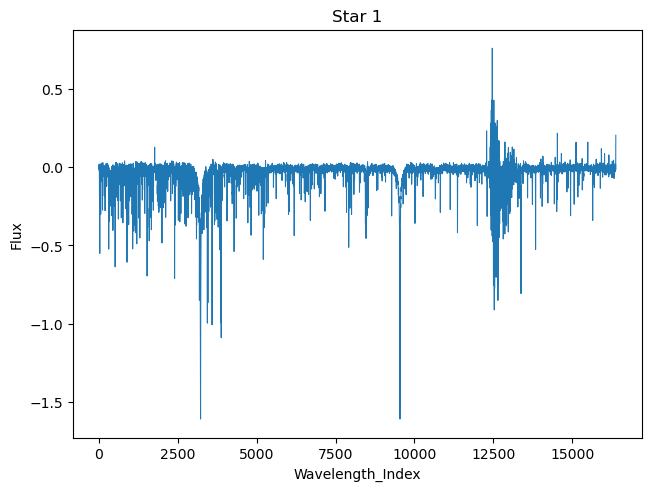

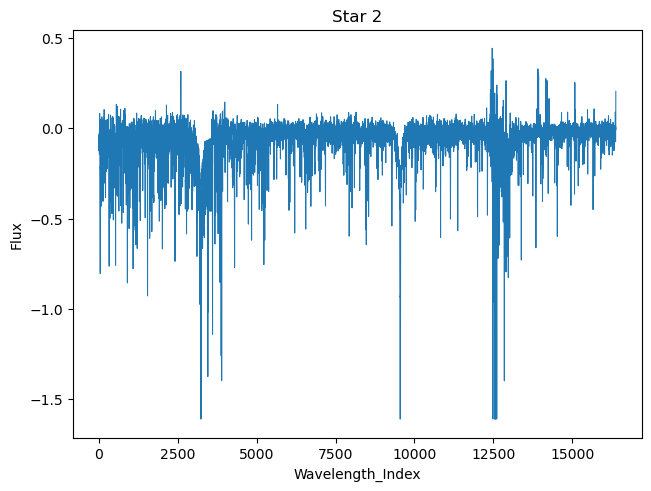

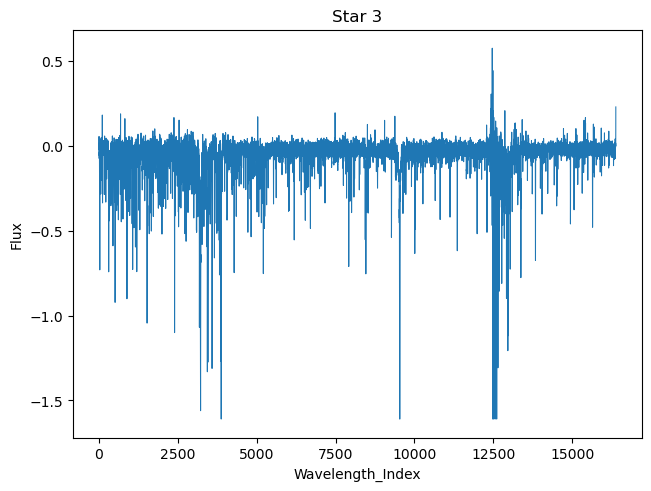

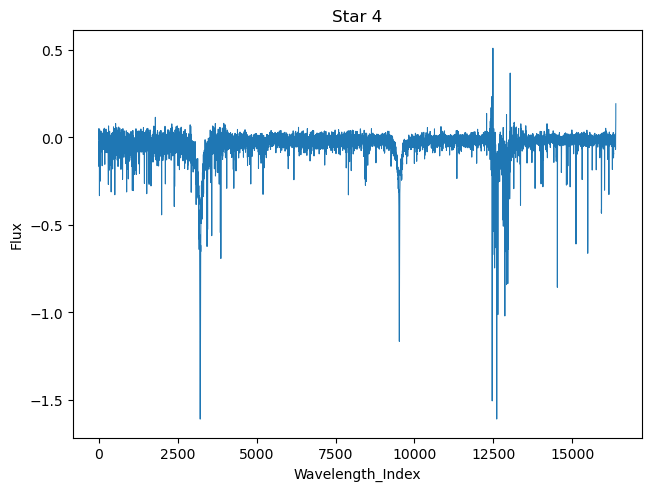

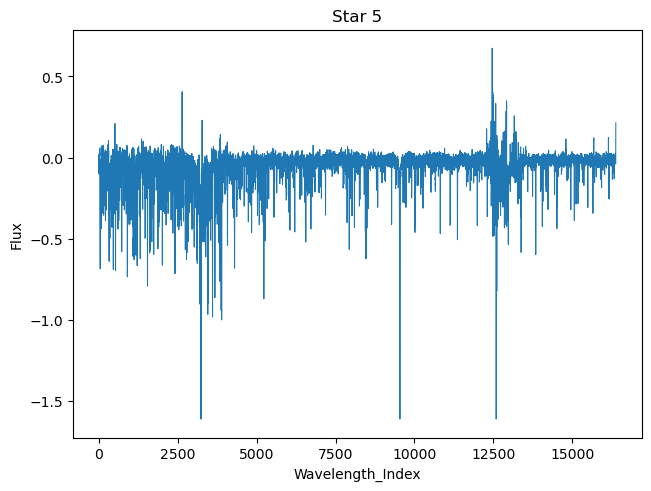

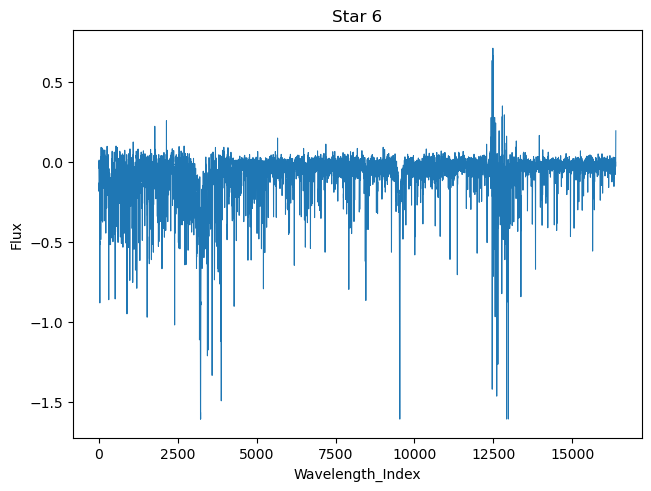

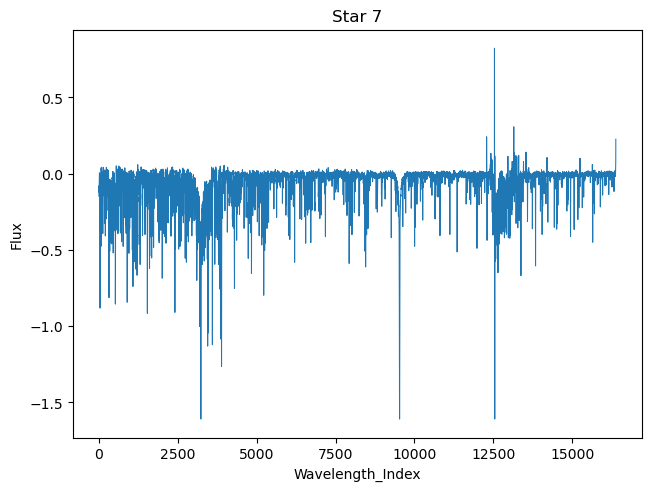

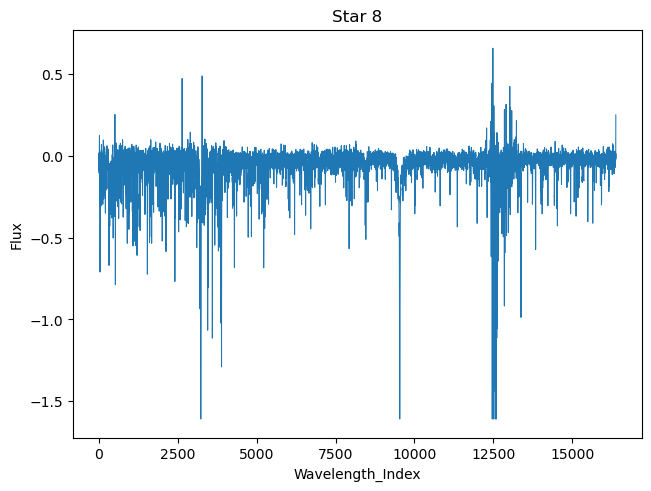

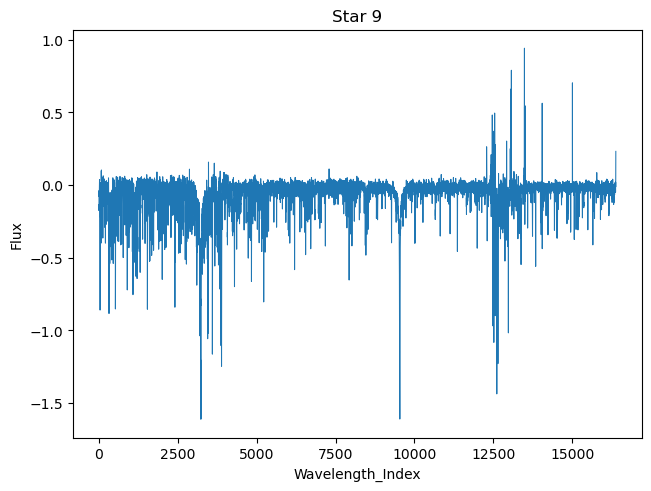

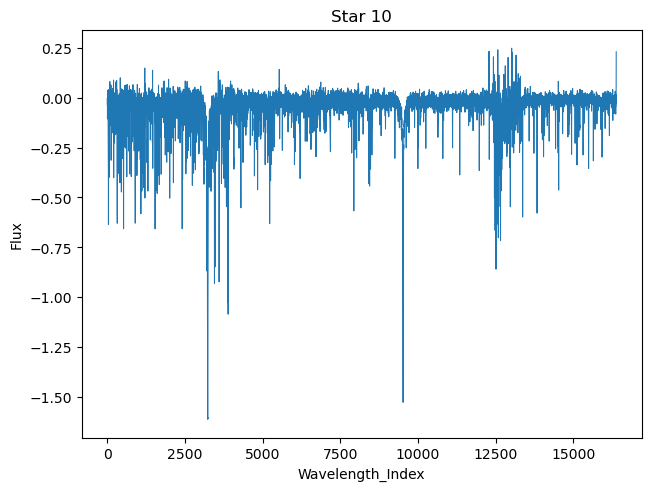

In [4]:
# Plotting a few spectra
for i in range(10):
    fig, ax = plt.subplots(1, 1, layout='constrained')
    ax.plot(spectra[i], lw=0.75) # lw = linewidth. Smaller to increase visibility.
    ax.set(
        title=(f'Star {i+1}'),
        xlabel=('Wavelength_Index'),
        ylabel=('Flux')
    )

**Implementing a CNN network**

In [5]:
# Defining the device pytorch in running on
device = (
    'cuda' if torch.cuda.is_available()
    else 'cpu'
)

# Defining the Dataset-class to connect the dataset-points of X and y and define a length.
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Constructing the data tensors for pytorch
X_tensor = (
    torch.as_tensor(spectra, dtype=torch.float32)
    .to(device)
)

y_tensor = (
    torch.as_tensor(labels, dtype=torch.float32)
    .to(device)
)
    
### Splitting the data and creating the dataset ###
n_samples = spectra.shape[0]

train_size = int(0.7 * n_samples)
val_size = int(0.15 * n_samples)
test_size = n_samples - train_size - val_size

# Using the customized dataset class for our dataset
dataset = CustomDataset(X_tensor, y_tensor)

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

# Dataloaders for the CNN where the training parameters are set (e.g. batch size)
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

In [6]:
# Defining the CNN model
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1),  
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, padding=1),
            nn.Dropout(0.2),
            nn.Conv1d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(in_features=32, out_features=3)
        )

    def forward(self, X):
        return self.net(X)

In [7]:
# Loss function
class CustomLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred, target):
        return torch.mean((pred - target)**2)

# Training
model = CNN().to(device)
loss_fn = CustomLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

n_epochs = 3
train_losses, val_losses = [], []

for epoch in range(n_epochs):

    # Training
    model.train()
    train_loss = 0
    print(epoch)
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        batch_x = batch_x.unsqueeze(1)
        predictions = model(batch_x)

        loss = loss_fn(predictions, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.unsqueeze(1)
            predictions = model(batch_x)
    
            loss = loss_fn(predictions, batch_y)
    
            val_loss += loss.item()
    
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

    # Testing
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.unsqueeze(1)
            predictions = model(batch_x)
    
            loss = loss_fn(predictions, batch_y)
    
            test_loss += loss.item()
    
        test_loss /= len(test_loader)

    # Logging 
    writer.add_scalar('loss_train', train_loss, epoch)
    writer.add_scalar('val_train', val_loss, epoch)
    writer.add_scalar('test_train', test_loss, epoch)
    
writer.close()

0
1
2


In [1]:
#%load_ext tensorboard
#%tensorboard --logdir=tensorboard_dir

#pkg_resources nicht installiert. Alles neu installiert und env sogar neu aufgesetzt.